In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from pathlib import Path

import MF_class as MF

np.random.seed(42)
if np.random.choice(np.arange(1000)) != 102:
    raise ValueError("Random seed is not set correctly.")

# 1. Choose Dataset

In [5]:
datasets = ['ml-1m', 'steam', 'goodreads']
DATASET = datasets[1]

base_artifacts = Path.cwd().resolve().parents[1] / 'CausalI2I_artifacts'
data_path = base_artifacts / 'Datasets' / 'Processed' / DATASET

# 2. Load Data

In [6]:
train = pd.read_csv(data_path / 'train.csv')
test = pd.read_csv(data_path / 'test.csv')
with open(data_path / 'item_dict.pkl', 'rb') as f:
    item_dict = pickle.load(f)

n_users = train['user_id'].nunique()
n_items = train['item_id'].nunique()
print(f'Number of users: {n_users}, Number of items: {n_items}')

Number of users: 8364, Number of items: 12434


In [7]:
model_path = base_artifacts / 'Propensity_Models'
with open(model_path / f'MF_params_{DATASET}.pkl', 'rb') as f:
    loaded_params = pickle.load(f)

In [8]:
name = f'MF_model_{DATASET}'

loaded_model = MF.MatrixFactorizationTorch(
    n_users=loaded_params['n_users'], 
    n_items=loaded_params['n_items'], 
    n_factors=loaded_params['n_factors']
)

model_path = base_artifacts / 'Propensity_Models'
loaded_model.load(path=model_path / (name + '.pt'))

Loaded model summary:
Model:                      MatrixFactorizationTorch
Number of users:            8364
Number of items:            12434
Number of factors:          50
Learning rate:              0.002
Weight decay:               1e-07
Positive weight:            1
Batch size:                 65536
Number of epochs:           30
Device:                     cuda:0
Use AMP:                    True
Timestamp:                  2026-04-10 15:42:53


# 3 Calibration Graph

In [9]:
new_df = train.copy()

u_idx = train['user_id'].values
i_idx = train['item_id'].values
probs = loaded_model.predict_prob(u_idx, i_idx).detach().numpy()
new_df['probs'] = probs

In [10]:
num_bins = 30

bins = np.quantile(probs, np.arange(0, 1, 1 / num_bins))
new_df['bin'] = np.digitize(probs, bins) - 1
grouped = new_df.groupby('bin')[['probs', 'interaction']].mean()

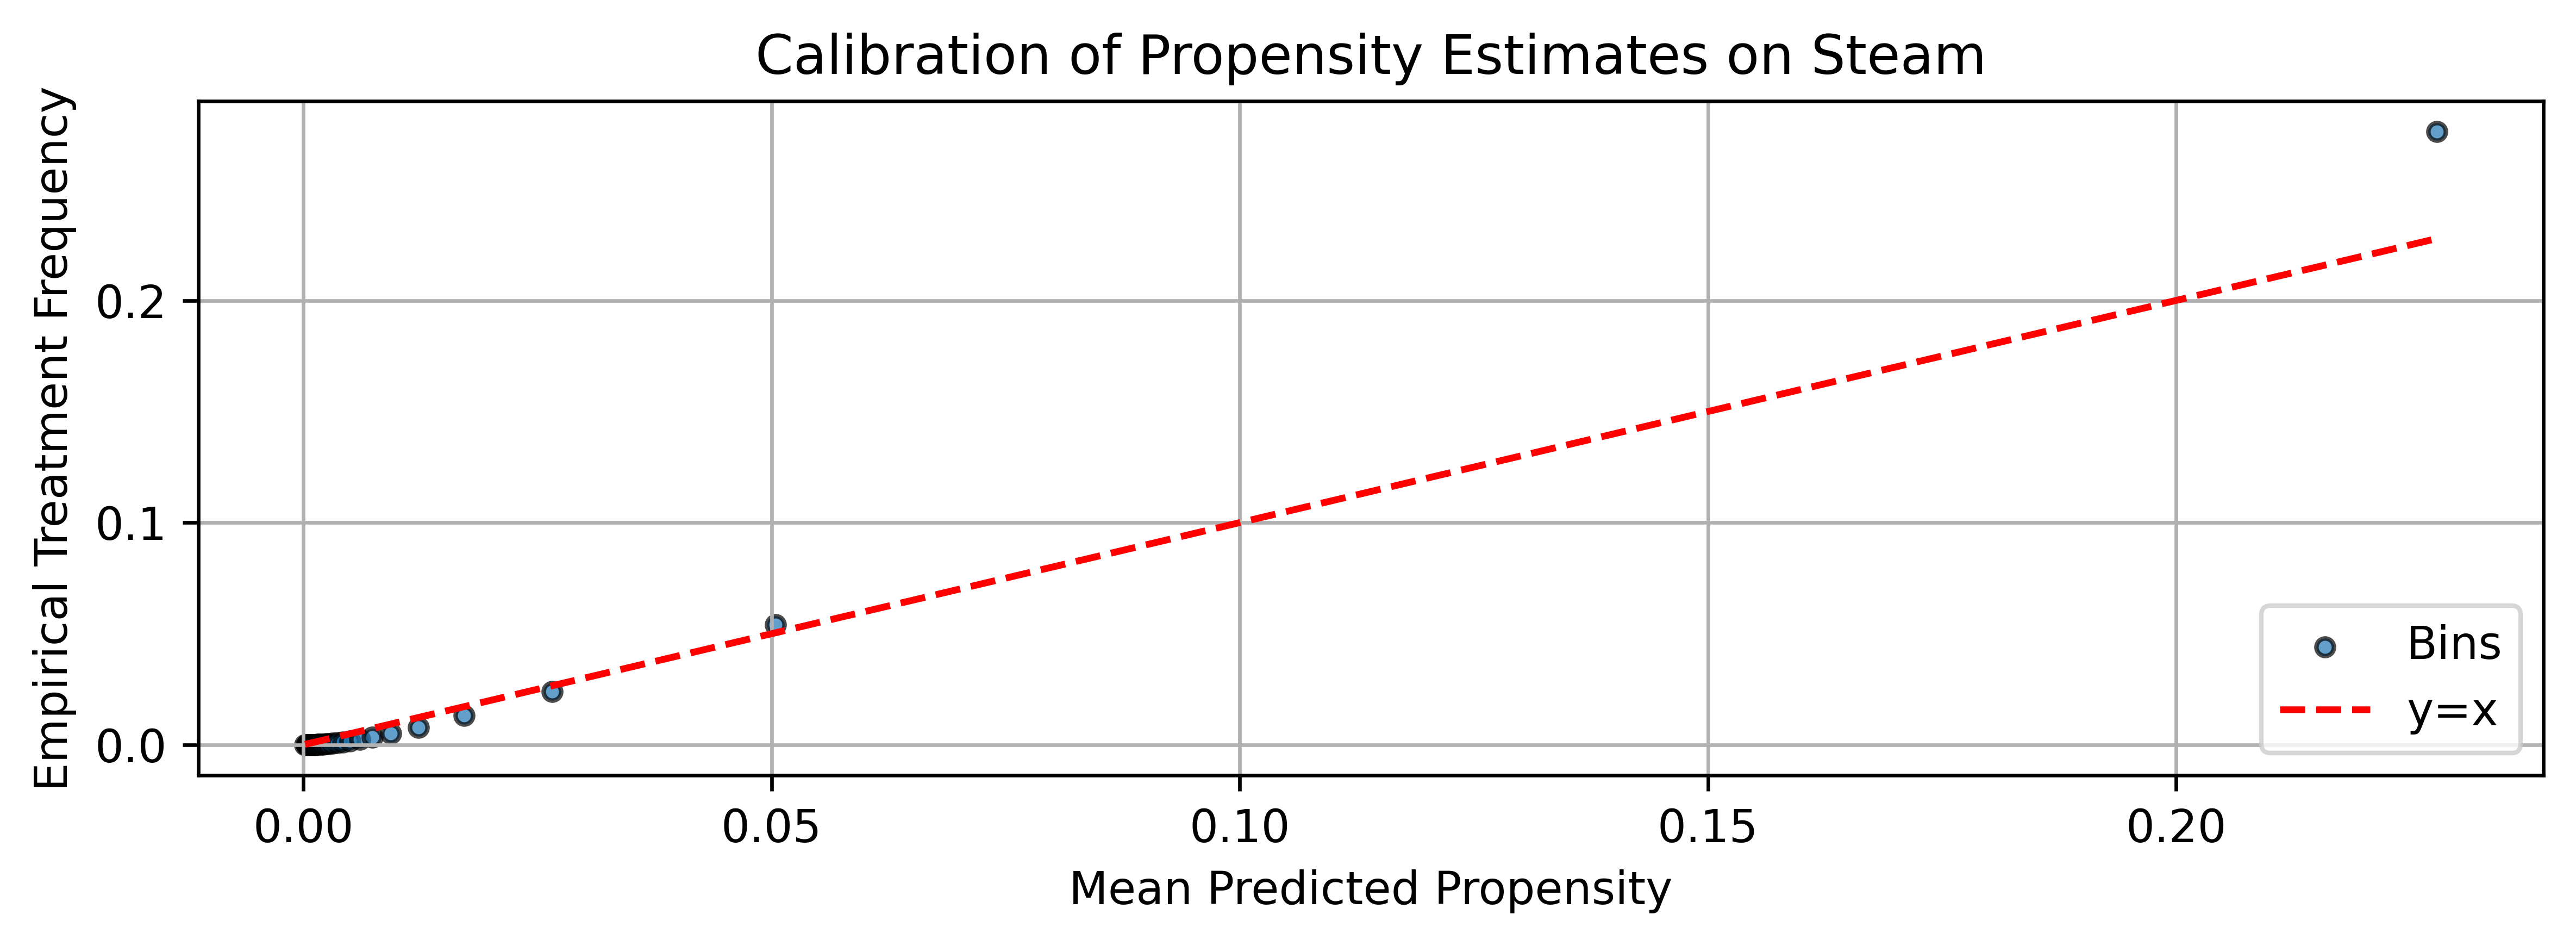

In [11]:
title_names = {
    'ml-1m': 'MovieLens-1M',
    'steam': 'Steam',
    'goodreads': 'Goodreads'
}

x = grouped['probs'].values
y = grouped['interaction'].values
X_samples = np.linspace(x.min(), x.max(), 1000)

plt.figure(figsize=(8, 3), dpi=600)

plt.scatter(
    x, 
    y, 
    marker='o',
    edgecolors='black', 
    s=15,
    linewidths=1,
    alpha=0.7, 
    label='Bins')
plt.plot(X_samples, X_samples, color='red', linestyle='--', label='y=x')

plt.title(f'Calibration of Propensity Estimates on {title_names[DATASET]}')
plt.xlabel('Mean Predicted Propensity')
plt.ylabel('Empirical Treatment Frequency')
plt.grid()
if DATASET == 'steam':
    plt.yticks([0.0, 0.1, 0.2])
plt.legend(loc='lower right')
plt.tight_layout()

plt.savefig(
    base_artifacts / 'Figures' / DATASET / 'calibration_plot.jpeg',
    bbox_inches='tight'
)

plt.show()

# 4 Further Analysis

In [12]:
calibration_errors = y - x

print('Calibration Errors Statistics:')
print(f'Min Calibration Error: {calibration_errors.min():.2e}')
print(f'Mean Calibration Error: {calibration_errors.mean():.2e}')
print(f'Max Calibration Error: {calibration_errors.max():.2e}')
print(f'Brier Score: {np.mean(calibration_errors**2):.2e}')


Calibration Errors Statistics:
Min Calibration Error: -4.38e-03
Mean Calibration Error: -6.09e-05
Max Calibration Error: 4.81e-02
Brier Score: 8.24e-05


### Create\Update CSV

In [13]:
existing_files = [item.name for item in model_path.iterdir()]
pickle_name = 'Calibration_Pickle.pkl'
if pickle_name in existing_files:
    with open(model_path / pickle_name, 'rb') as f:
        calibration_data = pickle.load(f)
else:
    calibration_data = {}

calibration_data[DATASET] = {
    'min_error': calibration_errors.min(),
    'mean_error': calibration_errors.mean(),
    'max_error': calibration_errors.max(),
    'ECE': np.mean(np.abs(calibration_errors)),
    'brier_score': np.mean(calibration_errors**2),
    'n_bins': num_bins
}

with open(model_path / pickle_name, 'wb') as f:
    pickle.dump(calibration_data, f)

In [14]:
text = ""
for data_key in calibration_data.keys():
    data_val = calibration_data[data_key]
    dataset_text = f"""Calibration analysis for {data_key}:
- Min Calibration Error: {data_val['min_error']:.2e}
- Mean Calibration Error: {data_val['mean_error']:.2e}
- Max Calibration Error: {data_val['max_error']:.2e}
- ECE: {data_val['ECE']:.2e}
- Brier Score: {data_val['brier_score']:.2e}
- Number of Bins: {data_val['n_bins']}
  
"""
    text += dataset_text

text_path = model_path / 'Calibration_Analysis_Summary.txt'
text_path.write_text(text)

607